Python DA Assignment 2 - Data Visualization
1) Loading the Taxis Dataset
import seaborn as sns
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

2) Handling Missing Values
➢ Check for missing values in the dataset and identify columns with missing data.
➢ Impute missing values using appropriate strategies based on the column type (e.g.,
using mean, median, or mode for numerical columns, and mode for categorical columns).
➢ For columns that are critical and cannot be reasonably imputed, remove rows with missing values to maintain data integrity.

In [24]:
import seaborn as sns
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

print(df.head())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [25]:
df.shape

(6433, 14)

In [26]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [27]:
print("Payment:", df['payment'].unique())
print("Pickup Zone:", df['pickup_zone'].unique())
print("Dropoff Zone:", df['dropoff_zone'].unique())
print("Pickup Borough:", df['pickup_borough'].unique())
print("Dropoff Borough:", df['dropoff_borough'].unique())

Payment: <StringArray>
['credit card', 'cash', nan]
Length: 3, dtype: str
Pickup Zone: <StringArray>
[          'Lenox Hill West',     'Upper West Side South',
             'Alphabet City',                 'Hudson Sq',
              'Midtown East', 'Times Sq/Theatre District',
         'Battery Park City',               'Murray Hill',
         'East Harlem South',       'Lincoln Square East',
 ...
           'Columbia Street',            'Middle Village',
             'Prospect Park',                'Ozone Park',
                 'Gravesend',                  'Glendale',
         'Kew Gardens Hills',        'Woodlawn/Wakefield',
    'West Farms/Bronx River',         'Hillcrest/Pomonok']
Length: 195, dtype: str
Dropoff Zone: <StringArray>
[    'UN/Turtle Bay South',   'Upper West Side South',
            'West Village',          'Yorkville West',
            'Midtown East', 'Two Bridges/Seward Park',
                'Flatiron',          'Midtown Center',
            'Central Park',     

In [28]:
#Finding the mode value for payment column
df['payment'].value_counts()

payment
credit card    4577
cash           1812
Name: count, dtype: int64

In [29]:
#filling the missing values in the payment column with the mode value
df["payment"] = df["payment"].fillna("credit card")

In [30]:
#Remove rows where all 4 location columns are missing
df = df.dropna(
    subset=['pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough'],how='all')

print(df.shape)

(6412, 14)


In [31]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment             0
pickup_zone         5
dropoff_zone       24
pickup_borough      5
dropoff_borough    24
dtype: int64

In [34]:
#find mode value for pickup_zone column using value_counts() method
df["pickup_zone"].value_counts()


pickup_zone
Midtown Center                  235
Upper East Side South           211
Penn Station/Madison Sq West    210
Clinton East                    208
Midtown East                    198
                               ... 
Ozone Park                        1
Glendale                          1
Woodlawn/Wakefield                1
West Farms/Bronx River            1
Hillcrest/Pomonok                 1
Name: count, Length: 194, dtype: int64

In [35]:
#filling the missing values in the pickup_zone column with the mode value
df["pickup_zone"] = df["pickup_zone"].fillna("Midtown Center")

In [36]:
#finding the mode value for dropoff_zone column using value_counts() method
df["dropoff_zone"].value_counts()

dropoff_zone
Upper East Side North    245
Murray Hill              220
Midtown Center           215
Upper East Side South    177
Midtown East             176
                        ... 
Queensboro Hill            1
Morrisania/Melrose         1
Madison                    1
Homecrest                  1
Brooklyn Navy Yard         1
Name: count, Length: 203, dtype: int64

In [37]:
#filling the missing values in the dropoff_zone column with the mode value
df["dropoff_zone"] = df["dropoff_zone"].fillna("Upper East Side North")

In [38]:
#finding the mode value for pickup_borough column using value_counts() method
df["pickup_borough"].value_counts()

pickup_borough
Manhattan    5268
Queens        657
Brooklyn      383
Bronx          99
Name: count, dtype: int64

In [39]:
#filling the missing values in the pickup_borough column with the mode value
df["pickup_borough"] = df["pickup_borough"].fillna("Manhattan")

In [40]:
#finding the mode value for dropoff_borough column using value_counts() method
df["dropoff_borough"].value_counts()

dropoff_borough
Manhattan        5206
Queens            542
Brooklyn          501
Bronx             137
Staten Island       2
Name: count, dtype: int64

In [41]:
#filling the missing values in the dropoff_borough column with the mode value
df["dropoff_borough"] = df["dropoff_borough"].fillna("Manhattan")

In [43]:
df.isnull().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [46]:
import pandas as pd

Line Chart  
Plot a line chart to visualize the fare over time, using the pickup timestamp as the 
x-axis and fare as the y-axis. Ensure the pickup column is converted to a datetime 
format before plotting. 

In [53]:
#covert pickup_datetime column to datetime format
df["pickup"] = pd.to_datetime(df["pickup"])
print(df["pickup"].dtype)

datetime64[us]


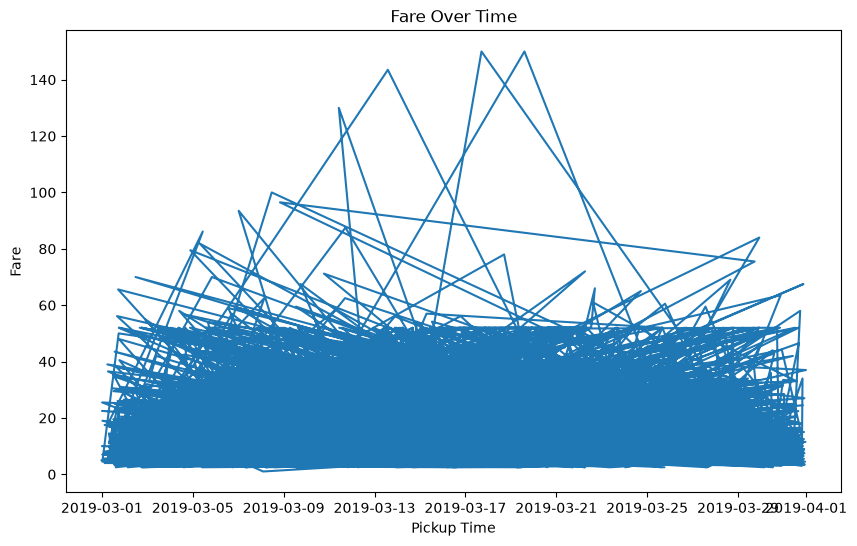

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df["pickup"],df["fare"])
plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title('Fare Over Time')

plt.show()

In [ ]:
#Bar Chart  
#Create a bar chart to show the total fare for each pickup_borough. Group the data by pickup_borough and sum the fare for each group.

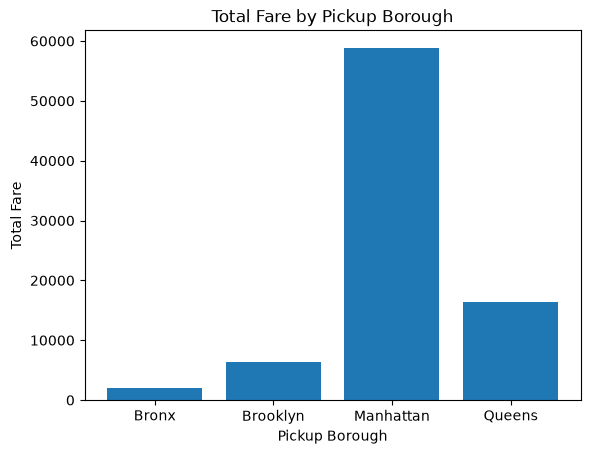

In [60]:
total_fare_by_borough = df.groupby("pickup_borough")["fare"].sum().reset_index()

plt.bar(total_fare_by_borough['pickup_borough'], total_fare_by_borough['fare']) 

plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')
plt.show()

 Pie Chart  
Plot a pie chart showing the distribution of trips based on the payment method (credit card, cash, etc.). Each slice should represent the count of trips for a specific payment 
method. 

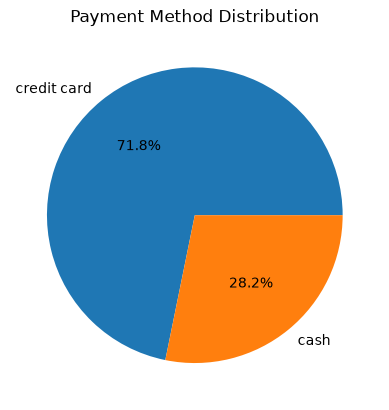

In [61]:
payment_counts = df["payment"].value_counts()

plt.pie(payment_counts, labels=payment_counts.index, autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.show()

Histogram  
Create a histogram to visualize the distribution of distance. Customize the number of 
bins for better granularity and ensure the plot is easy to interpret. 

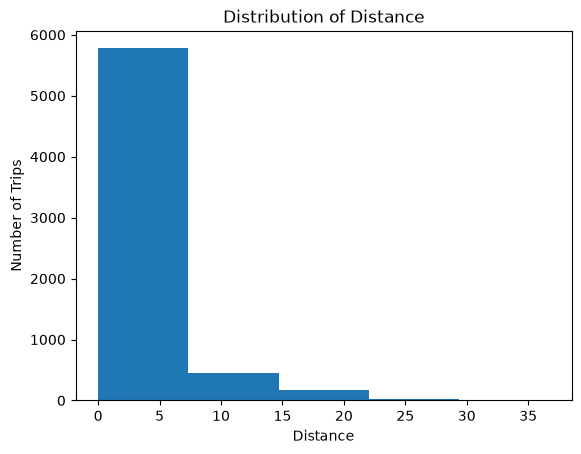

In [73]:
plt.hist(df["distance"],bins=5)
plt.title("Distribution of Distance")
plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.show()

 Box Plot  
Plot a box plot to visualize the distribution of tip amounts for each pickup_borough. 
Use pickup_borough as the categorical axis and tip as the numeric axis.

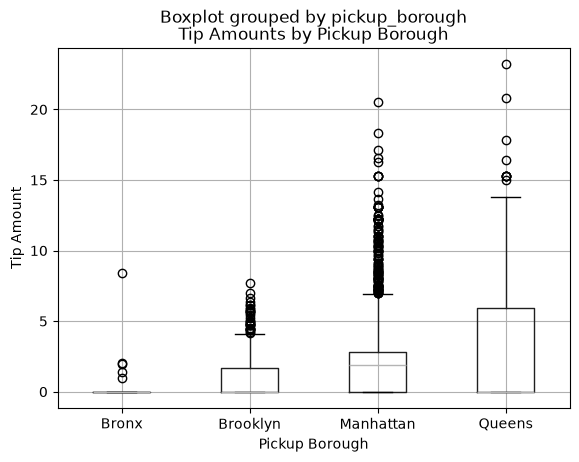

In [82]:

df.boxplot(column='tip', by='pickup_borough')
plt.title("Tip Amounts by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.show()

Visualizations using Seaborn: 
★ Count Plot  
Create a count plot to visualize the number of trips in each pickup_borough. The 
x-axis should represent the boroughs, and the y-axis should show the count of trips

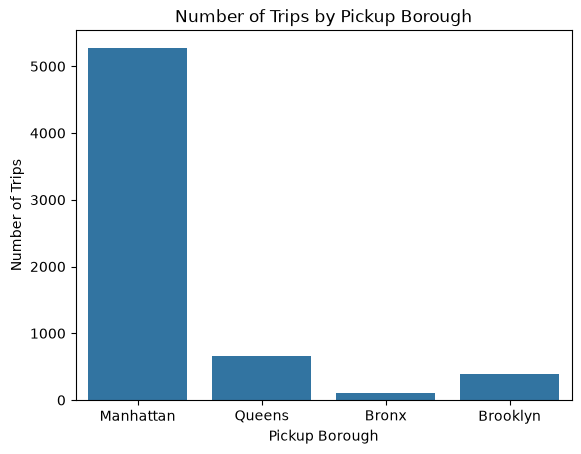

In [83]:
import seaborn as sns

sns.countplot(data=df, x="pickup_borough")
plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.show()

Scatter Plot  
Plot a scatter plot to show the relationship between distance and fare. Use distance on the x-axis and fare on the y-axis to visualize any correlation. Color the 
points based on the pickup_borough to differentiate the trips by their respective 
boroughs. 

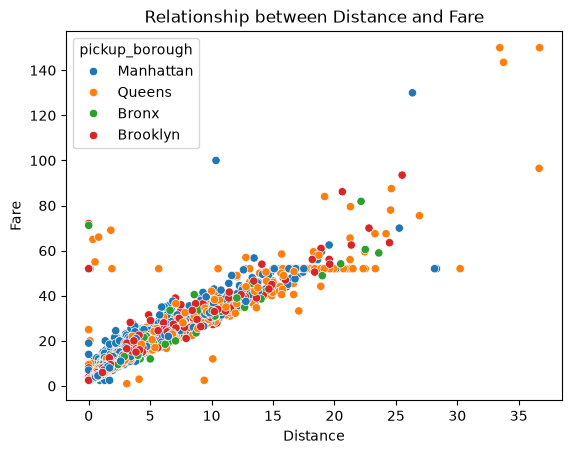

In [85]:
sns.scatterplot(data=df, x="distance", y="fare", hue="pickup_borough")
plt.title("Relationship between Distance and Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.show()

Heatmap  
Plot a heatmap to visualize the correlation between numerical variables such as 
distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the 
relationships

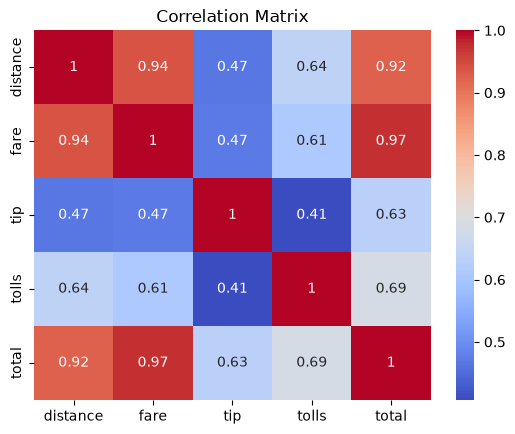

In [ ]:
corr = df[["distance", "fare", "tip", "tolls", "total"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Pair Plot  
Create a pair plot to visualize the pairwise relationships between distance, fare, tip, 
and total. Color the data points according to the pickup_zone method to compare 
how different zones affect these variables. 

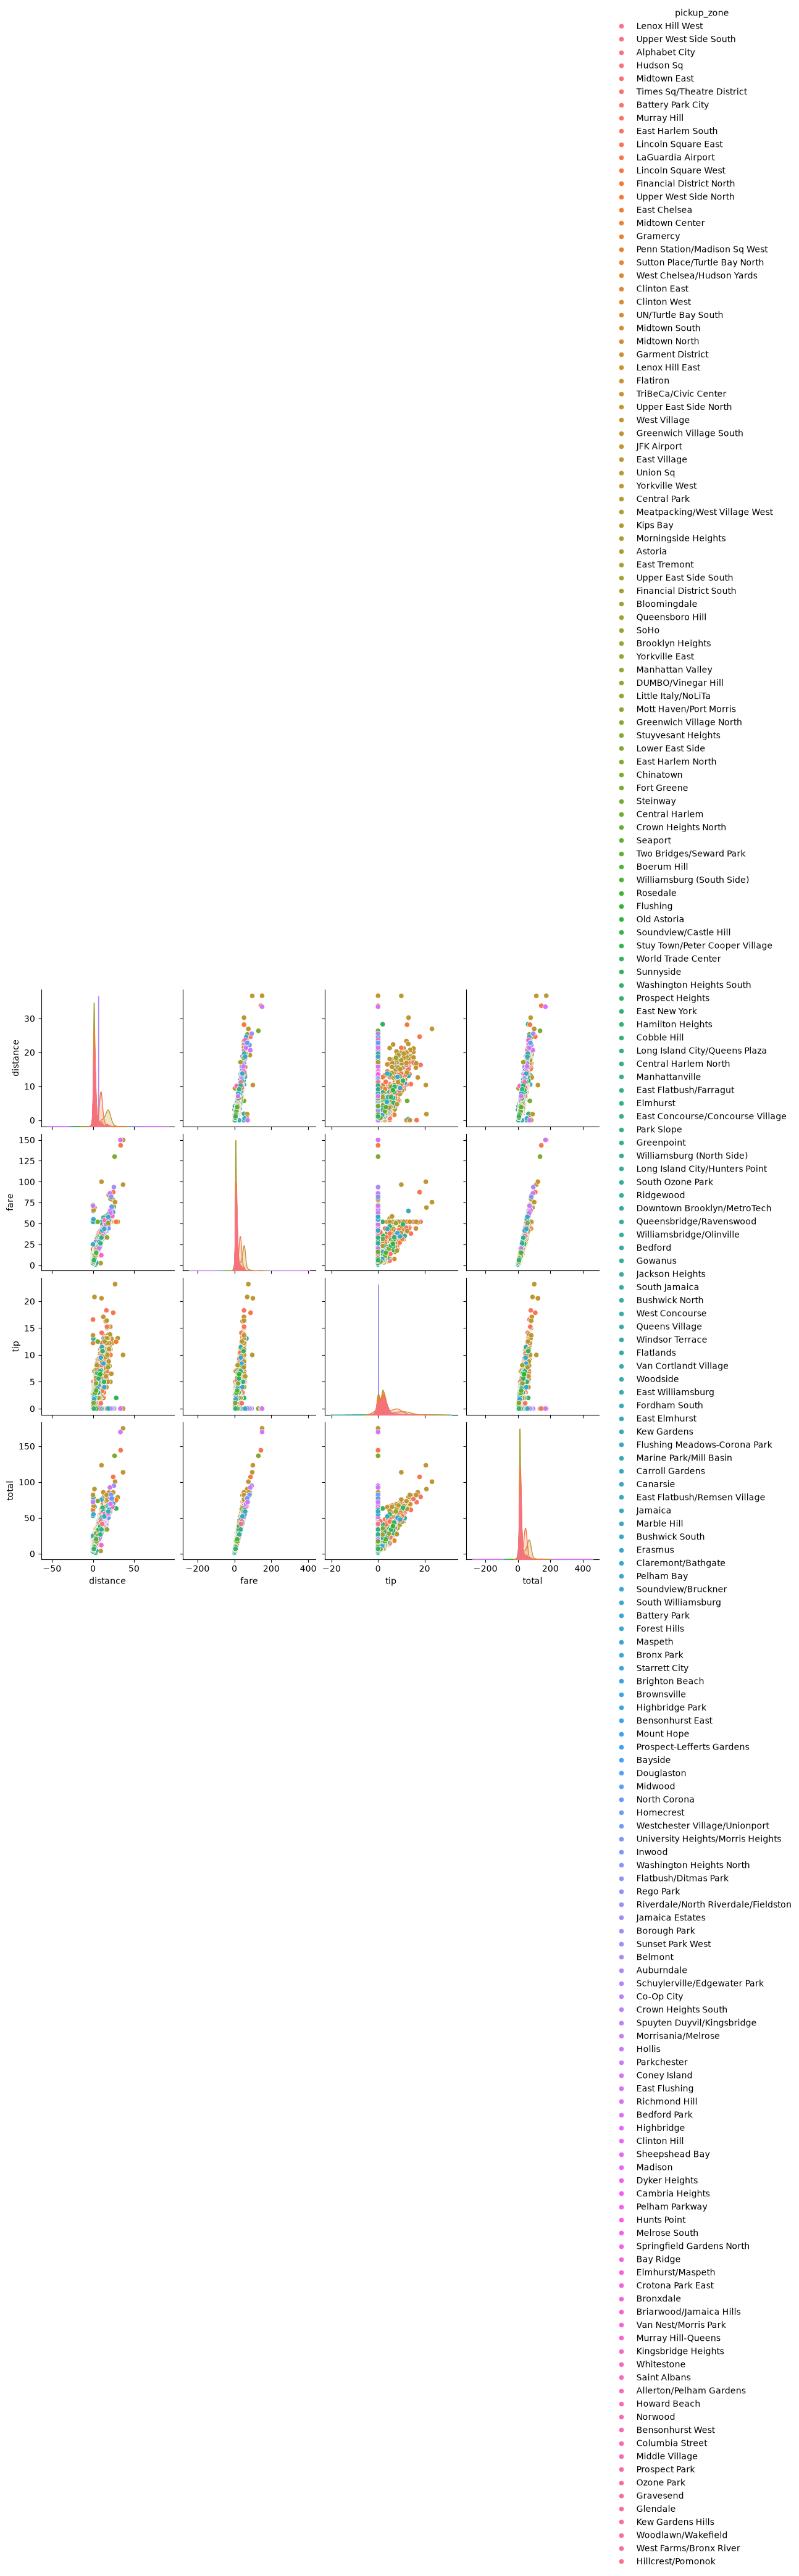

In [87]:
sns.pairplot(df,vars=["distance","fare","tip","total"],hue="pickup_zone")
plt.show()

 Violin Plot  
Plot a violin plot to show the distribution of fare for each payment method. Use the 
payment method as the categorical axis and fare as the numeric axis to visualize its 
distribution.

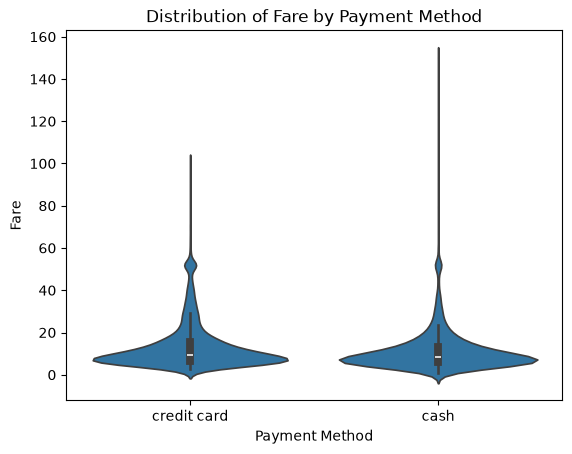

In [90]:
sns.violinplot(data=df, x="payment", y="fare")
plt.title("Distribution of Fare by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.show()